In [1]:
import subprocess
subprocess.run(["pip", "install", "cwru"], capture_output=True)

CompletedProcess(args=['pip', 'install', 'cwru'], returncode=0, stdout=b'Requirement already satisfied: cwru in c:\\users\\slime\\.conda\\envs\\bearing\\lib\\site-packages (0.2)\r\nRequirement already satisfied: numpy in c:\\users\\slime\\.conda\\envs\\bearing\\lib\\site-packages (from cwru) (2.2.6)\r\nRequirement already satisfied: scipy in c:\\users\\slime\\.conda\\envs\\bearing\\lib\\site-packages (from cwru) (1.15.3)\r\n', stderr=b'')

In [3]:
import urllib.request
import os

# 创建目录
os.makedirs("data", exist_ok=True)

# 下载4个文件（正常、内圈、外圈、滚动体故障）
files = {
    "normal.mat": "https://engineering.case.edu/sites/default/files/97.mat",
    "inner_fault.mat": "https://engineering.case.edu/sites/default/files/105.mat",
    "outer_fault.mat": "https://engineering.case.edu/sites/default/files/130.mat",
    "ball_fault.mat": "https://engineering.case.edu/sites/default/files/118.mat"
}

for name, url in files.items():
    path = f"data/{name}"
    if os.path.exists(path):
        print(f"{name} 已存在，跳过")
        continue
    print(f"正在下载 {name}...")
    urllib.request.urlretrieve(url, path)
    print(f"{name} 下载完成")

print("\n全部完成！")
print("文件列表：", os.listdir("data"))

正在下载 normal.mat...
normal.mat 下载完成
正在下载 inner_fault.mat...
inner_fault.mat 下载完成
正在下载 outer_fault.mat...
outer_fault.mat 下载完成
正在下载 ball_fault.mat...
ball_fault.mat 下载完成

全部完成！
文件列表： ['ball_fault.mat', 'inner_fault.mat', 'normal.mat', 'outer_fault.mat']


In [5]:
import scipy.io
import numpy as np

def load_mat(path, key):
    mat = scipy.io.loadmat(path)
    # 找到振动信号的key
    for k in mat.keys():
        if 'DE_time' in k:
            return mat[k].flatten()
    return None

# 读取4个文件
normal = load_mat("data/normal.mat", "normal")
inner  = load_mat("data/inner_fault.mat", "inner")
outer  = load_mat("data/outer_fault.mat", "outer")
ball   = load_mat("data/ball_fault.mat", "ball")

print("正常信号长度:", len(normal))
print("内圈故障长度:", len(inner))
print("外圈故障长度:", len(outer))
print("滚动体故障长度:", len(ball))

正常信号长度: 243938
内圈故障长度: 121265
外圈故障长度: 121991
滚动体故障长度: 122571


In [6]:
def segment_signal(signal, seg_len=512, step=256):
    """把长信号切成固定长度的小段"""
    segments = []
    for i in range(0, len(signal) - seg_len, step):
        segments.append(signal[i:i+seg_len])
    return np.array(segments)

# 切分每类信号
X_normal = segment_signal(normal)
X_inner  = segment_signal(inner)
X_outer  = segment_signal(outer)
X_ball   = segment_signal(ball)

print("每类样本数量:")
print(f"  正常: {len(X_normal)}")
print(f"  内圈: {len(X_inner)}")
print(f"  外圈: {len(X_outer)}")
print(f"  滚动体: {len(X_ball)}")

# 合并 + 生成标签（0=正常 1=内圈 2=外圈 3=滚动体）
X = np.vstack([X_normal, X_inner, X_outer, X_ball])
y = np.array([0]*len(X_normal) + [1]*len(X_inner) + 
             [2]*len(X_outer)  + [3]*len(X_ball))

print(f"\n总样本数: {len(X)}, 特征维度: {X.shape}")

每类样本数量:
  正常: 951
  内圈: 472
  外圈: 475
  滚动体: 477

总样本数: 2375, 特征维度: (2375, 512)


In [7]:
from scipy.fft import fft

def extract_features(segment):
    """提取时域+频域特征"""
    # 时域特征
    rms      = np.sqrt(np.mean(segment**2))
    peak     = np.max(np.abs(segment))
    crest    = peak / (rms + 1e-8)
    kurtosis = np.mean((segment - np.mean(segment))**4) / (np.std(segment)**4 + 1e-8)
    skew     = np.mean((segment - np.mean(segment))**3) / (np.std(segment)**3 + 1e-8)
    
    # 频域特征
    fft_vals  = np.abs(fft(segment))[:len(segment)//2]
    freq_mean = np.mean(fft_vals)
    freq_std  = np.std(fft_vals)
    freq_peak = np.max(fft_vals)
    
    return [rms, peak, crest, kurtosis, skew, freq_mean, freq_std, freq_peak]

# 对所有样本提取特征
X_features = np.array([extract_features(seg) for seg in X])
print("特征矩阵大小:", X_features.shape)
print("特征名称: rms, peak, crest, kurtosis, skew, freq_mean, freq_std, freq_peak")

特征矩阵大小: (2375, 8)
特征名称: rms, peak, crest, kurtosis, skew, freq_mean, freq_std, freq_peak


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import joblib

# 划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=42, stratify=y
)

# 标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 训练两个模型做对比
models = {
    "随机森林": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM":     SVC(kernel='rbf', probability=True, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n{name} 准确率: {acc:.4f} ({acc*100:.2f}%)")

# 选最好的保存
best_name = max(results, key=results.get)
best_model = models[best_name]
print(f"\n最优模型: {best_name}，准确率 {results[best_name]*100:.2f}%")

# 保存模型和scaler
os.makedirs("model", exist_ok=True)
joblib.dump(best_model, "model/model.pkl")
joblib.dump(scaler, "model/scaler.pkl")
print("模型已保存到 model/ 文件夹")


随机森林 准确率: 1.0000 (100.00%)

SVM 准确率: 1.0000 (100.00%)

最优模型: 随机森林，准确率 100.00%
模型已保存到 model/ 文件夹


              precision    recall  f1-score   support

          正常       1.00      1.00      1.00       190
        内圈故障       1.00      1.00      1.00        95
        外圈故障       1.00      1.00      1.00        95
       滚动体故障       1.00      1.00      1.00        95

    accuracy                           1.00       475
   macro avg       1.00      1.00      1.00       475
weighted avg       1.00      1.00      1.00       475



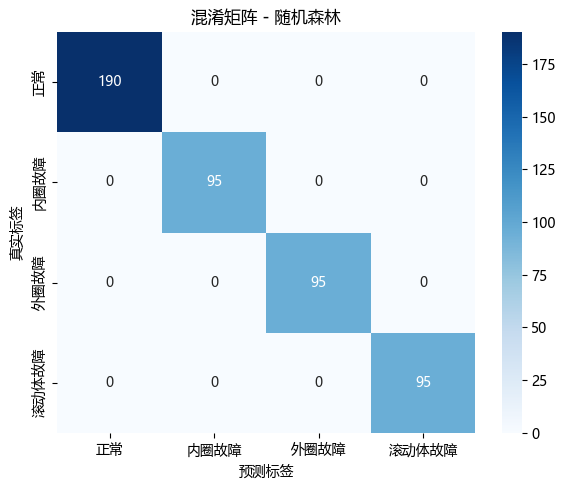

混淆矩阵已保存


In [9]:
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import confusion_matrix
import seaborn as sns

matplotlib.rcParams['font.family'] = 'Microsoft YaHei'  # 支持中文

labels = ["正常", "内圈故障", "外圈故障", "滚动体故障"]

# 用最优模型预测
y_pred = best_model.predict(X_test_scaled)

# 打印详细报告
print(classification_report(y_test, y_pred, target_names=labels))

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title(f"混淆矩阵 - {best_name}")
plt.ylabel("真实标签")
plt.xlabel("预测标签")
plt.tight_layout()
plt.savefig("model/confusion_matrix.png", dpi=150)
plt.show()
print("混淆矩阵已保存")